In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load Iris Dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

print("✅ Dataset Loaded!")
print("Shape:", df.shape)
df.head()

✅ Dataset Loaded!
Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


=== Dataset Info ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing Values: 0

Class Distribution:
species
set

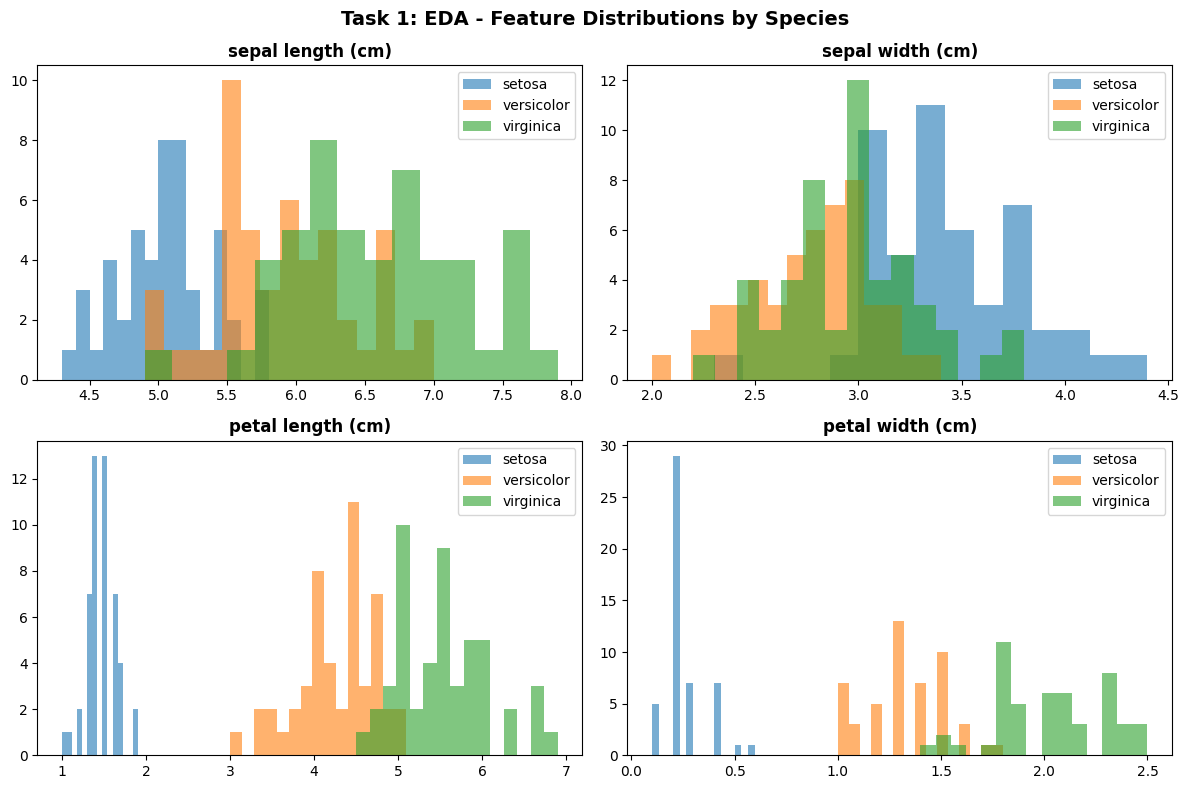

In [2]:
print("=== Dataset Info ===")
print(df.describe())
print("\nMissing Values:", df.isnull().sum().sum())
print("\nClass Distribution:")
print(df['species'].value_counts())

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
features = iris.feature_names
for i, col in enumerate(features):
    for species in df['species'].unique():
        subset = df[df['species']==species][col]
        axes[i].hist(subset, alpha=0.6, label=species, bins=15)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()
plt.suptitle('Task 1: EDA - Feature Distributions by Species',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
# Features and Target
X = df[iris.feature_names]
y = df['target']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data Scaled!")
print("Before scaling - Mean:", X.mean().mean().round(2))
print("After scaling  - Mean:", X_scaled.mean().round(2))
print("After scaling  - Std :", X_scaled.std().round(2))

✅ Data Scaled!
Before scaling - Mean: 3.46
After scaling  - Mean: -0.0
After scaling  - Std : 1.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data Split Done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

✅ Data Split Done!
Training samples : 120
Testing  samples : 30


In [5]:
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")
print("Classes:", model.classes_)

✅ Model Trained Successfully!
Classes: [0 1 2]


In [6]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"✅ Accuracy  : {accuracy * 100:.2f}%")
print(f"✅ F1 Score  : {f1:.4f}")
print("=" * 40)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['setosa','versicolor','virginica']))

       MODEL EVALUATION RESULTS
✅ Accuracy  : 100.00%
✅ F1 Score  : 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



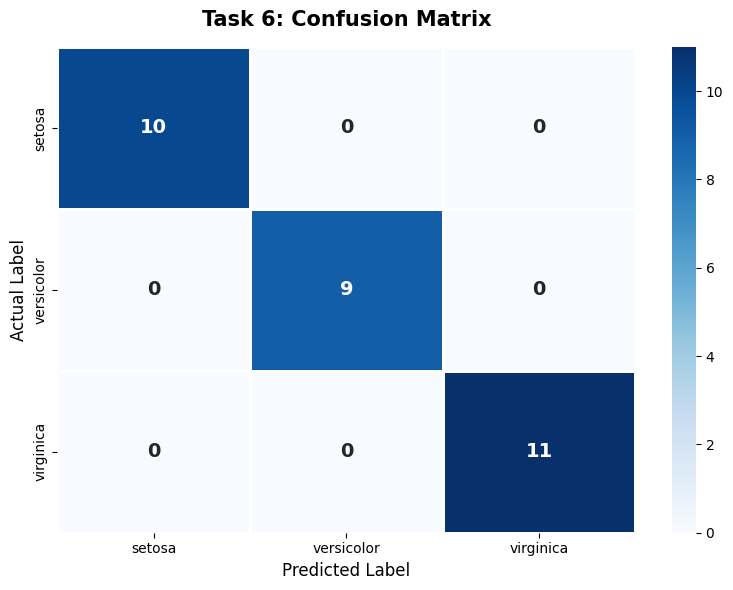


How to read Confusion Matrix:
Diagonal = Correct predictions ✅
Off-diagonal = Wrong predictions ❌


In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa','versicolor','virginica'],
            yticklabels=['setosa','versicolor','virginica'],
            linewidths=1, linecolor='white',
            annot_kws={'size':14, 'weight':'bold'})
plt.title('Task 6: Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nHow to read Confusion Matrix:")
print("Diagonal = Correct predictions ✅")
print("Off-diagonal = Wrong predictions ❌")

INTERVIEW QUESTIONS — ANSWERS
══════════════════════════════════════════════════════

Q1. Why 'Regression' for classification?
    Logistic Regression uses the Sigmoid function to
    convert output into probability (0 to 1).
    If probability > 0.5 → Class 1, else → Class 0.
    So despite the name, it IS a classification algorithm.

Q2. Role of Sigmoid Function?
    Sigmoid converts any number into a value between 0 and 1.
    Formula: f(x) = 1 / (1 + e^-x)
    This gives us the PROBABILITY of belonging to a class.

Q3. Binary vs Multinomial?
    Binary      = 2 classes only (Yes/No, Spam/Not Spam)
    Multinomial = 3 or more classes (setosa/versicolor/virginica)
    Iris dataset is MULTINOMIAL (3 classes).

Q4. Decision Boundary Significance?
    Decision boundary is the line that separates classes.
    Logistic Regression finds the BEST line/boundary
    to separate classes with maximum accuracy.

══════════════════════════════════════════════════════
